## Overview

CNN-GRU Setup for prediction out of 2D timeseries data

finding out of impact of training on "wrong" year of the saison

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 3.6.

next step: get the window method in the dataset class to the agreed format

In [1]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

import xarray as xr

rSeed=42

SavePlots = False

## Loading Data

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
!cd drive/MyDrive/small_grid && ls

dataloaders			       grid-timeseries_sel_vars_2016.grib.nc
grib_to_pd_dataset.ipynb	       grid-timeseries_sel_vars_2017.grib.nc
grid-timeseries_sel_vars_1940.grib.nc  grid-timeseries_sel_vars_2018.grib.nc
grid-timeseries_sel_vars_1950.grib.nc  grid-timeseries_sel_vars_2019.grib.nc
grid-timeseries_sel_vars_1960.grib.nc  grid-timeseries_sel_vars_2020.grib.nc
grid-timeseries_sel_vars_1970.grib.nc  grid-timeseries_sel_vars_2021.grib.nc
grid-timeseries_sel_vars_1980.grib.nc  grid-timeseries_sel_vars_2022.grib.nc
grid-timeseries_sel_vars_1990.grib.nc  grid-timeseries_sel_vars_2023.grib.nc
grid-timeseries_sel_vars_2000.grib.nc  grid-timeseries_sel_vars_2024.grib.nc
grid-timeseries_sel_vars_2010.grib.nc  grid-timeseries_sel_vars_2025.grib.nc
grid-timeseries_sel_vars_2015.grib.nc


In [4]:
from pathlib import Path

folder = "drive/MyDrive/small_grid"
filelist = [p.name for p in Path(folder).iterdir() if p.is_file()]

print(filelist)

['grid-timeseries_sel_vars_1940.grib.nc', 'grid-timeseries_sel_vars_1950.grib.nc', 'grid-timeseries_sel_vars_1960.grib.nc', 'grid-timeseries_sel_vars_1970.grib.nc', 'grid-timeseries_sel_vars_1980.grib.nc', 'grid-timeseries_sel_vars_1990.grib.nc', 'grid-timeseries_sel_vars_2000.grib.nc', 'grid-timeseries_sel_vars_2010.grib.nc', 'grid-timeseries_sel_vars_2020.grib.nc', 'grid-timeseries_sel_vars_2015.grib.nc', 'grid-timeseries_sel_vars_2016.grib.nc', 'grid-timeseries_sel_vars_2017.grib.nc', 'grid-timeseries_sel_vars_2018.grib.nc', 'grid-timeseries_sel_vars_2019.grib.nc', 'grid-timeseries_sel_vars_2021.grib.nc', 'grid-timeseries_sel_vars_2022.grib.nc', 'grid-timeseries_sel_vars_2023.grib.nc', 'grid-timeseries_sel_vars_2024.grib.nc', 'grid-timeseries_sel_vars_2025.grib.nc', 'grib_to_pd_dataset.ipynb']


In [5]:
#only select recent years until 2015
years = [str(year) for year in range(1940,2015)]#recent: range (2015,2025), past:(1940, 2015)
print(years)

#filter the filelist to only include files for the selected years
filelist = [filename for filename in filelist if any(year in filename for year in years)]
print(filelist)

# Open the NetCDF files using xarray
ds={}
for filename in filelist:
    year = filename.split("_")[3]  # Extract the year from the filename
    ds[year]= xr.open_dataset(folder + "/" + filename)
ds.keys()

#combining the dict datasets into one xarray dataset
ds_combined = xr.concat([ds[year] for year in ds.keys()], dim='time')

#splitting into seasons
seasons={"spring": "MAM", "summer": "JJA", "autumn": "SON", "winter": "DJF"}
ds_seasons = {}
for season, code in seasons.items():
    ds_seasons[season] = ds_combined.sel(time=ds_combined['time.season'] == code)

['1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014']
['grid-timeseries_sel_vars_1940.grib.nc', 'grid-timeseries_sel_vars_1950.grib.nc', 'grid-timeseries_sel_vars_1960.grib.nc', 'grid-timeseries_sel_vars_1970.grib.nc', 'grid-timeseries_sel_vars_1980.grib.nc', 'grid-timeseries_sel_vars_1990.grib.nc', 'grid-timeseries_sel_vars_2000.grib.nc', 'grid-timeseries_sel_vars_2010.grib.nc']


In [6]:
class TimeseriesDatasetPipeline:
    """Pipeline to convert xarray Dataset to PyTorch Dataset with optional scaling."""
    
    def __init__(self, ds,lag_selection=None, forecast_horizon=24,forecast_hours=1,forecast_var=5):
        """
        Initialize the pipeline.
        
        Args:
            ds: xarray.Dataset with dimensions (time, lat, lon)
            scaler: sklearn scaler object (optional, e.g., StandardScaler)
            forecast_lag: number of past timesteps to use as input
            forecast_horizon: number of future timesteps to predict
        """
        self.ds = ds
        self.lag_selection = lag_selection
        self.forecast_horizon = forecast_horizon
        self.forecast_var = forecast_var
        self.forecast_hours = forecast_hours
        self.data = None
        self._prepare_data()
        if self.forecast_var >= self.data.shape[1]:
            raise ValueError(f"forecast_var index {self.forecast_var} is out of bounds for data with {self.data.shape[1]} variables.")
    

    def get_input_shape(self):
        """Return the shape of the input data (time, variables, space)."""
        return self.ds.to_array().values.shape if self.ds is not None else None

    def _prepare_data(self):
        """Convert xarray to numpy, flatten spatial dimensions and reshape."""
        stacked = self.ds.to_array()
        self.data = stacked.values.transpose(1, 0, 2,3)#(time, variables, lat,lon)
        print("Data prepared with shape:", self.data.shape)


    def scale_X(self,shaped_data,scaler_set=None):
        """Apply each scaler to the corresponding variable."""
        scaled=shaped_data
        if scaler_set is None:  sc_set=np.array([])
        else: sc_set=scaler_set
        for i in range(scaled.shape[-3]):#in vars
            reshaped_var = scaled[:,:, i, :].reshape(-1, 1)
            if scaler_set is None:#scaler set not functional
                sc_set = np.append(sc_set, sklearn.preprocessing.StandardScaler().fit(reshaped_var))
            sh=scaled.shape[0], scaled.shape[1],scaled.shape[3], scaled.shape[4]
            scaled[:,:, i, :] = sc_set[i].transform(reshaped_var).reshape(sh)
        return scaled, sc_set
   
    def scale_y(self,shaped_data,scaler=None):
        """Apply scaler to the corresponding variable."""
        scaled=shaped_data
        reshaped_var = scaled.reshape(-1, 1)
        if scaler is None:
            scaler=sklearn.preprocessing.StandardScaler().fit(reshaped_var)
        sh=scaled.shape[0],1,scaled.shape[2], scaled.shape[3]
        scaled = scaler.transform(reshaped_var).reshape(sh)
        return scaled,scaler
    



    def create_windowed_dataset_from_idxlist(self, idx_list):
        """Create X and y using moving window method."""
        data = self.data
        if self.lag_selection:
            max_lag = max(self.lag_selection)+1
        else:
            raise ValueError("forecast_lag_selection must be provided.")
        
        X, y = [], []
        for i in idx_list:
            #print(f"Processing index {i} with lag selection {self.lag_selection} and forecast horizon {self.forecast_horizon}.")
            #print(f"\nforecast horizon: {self.forecast_horizon}, forecast var: {self.forecast_var}, lag selection: {self.lag_selection}")
            if i+max_lag+self.forecast_horizon >= len(data):
                print(f"Skipping index {i} due to insufficient data for lag selection and forecast horizon.")
                continue
            #testing, if there is enough consecutive data for the selected lags and forecast horizon in the time dimension, if not, skip this index
            last_timespan_idx=i+max_lag+self.forecast_horizon
            if self.ds.time[last_timespan_idx].values - self.ds.time[i].values > np.timedelta64(max_lag+self.forecast_horizon, 'h'):
                print(f"Skipping index {i} due to insufficient consecutive data for forecast horizon.")
                continue
            
            #print("Original data shape:", data.shape)
            data_filtered = []#filtering data based on lag selection
            for t in self.lag_selection:
                data_filtered.append(data[i+t,:,:])
            xd = np.array(data_filtered)  # (lag_selection, variables, space)
            #print("data_filtered:", getattr(xd, "shape", None))
            
            #xd=np.delete(data_filtered, self.forecast_var, axis=1)# Remove target variable from input
            #print("xd:", getattr(xd, "shape", None), type(xd),"\n")
            X.append(xd)
            yd=data[i+self.forecast_horizon,self.forecast_var,:]  # Only target variable
            yd=yd.reshape(1, yd.shape[0], yd.shape[1])
            y.append(yd)
            #print("yd:", getattr(yd, "shape", None), type(yd))

            #return test_end

        X = np.array(X) 
        y = np.array(y)  
        print("X:", X.shape, type(X))   # (samples, lag, variables, space)
        print("y:",y.shape, type(y))    # (samples, horizon, pred variable, space)
        return X,y


    def create_random_train_test_split_idx(self, test_size=0.2, random_state=None):
        """Create random train/test split indices."""
        total_samples = self.data.shape[0] - max(self.lag_selection) - self.forecast_horizon
        indices = np.arange(total_samples)
        train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=random_state)
        return train_idx, test_idx
    

    def to_scaled_pytorch_train_test_dataloaders(self, batch_size=32, test_size=0.2, random_state=None):
        """Create PyTorch DataLoader with random train/test split."""
        train_idx, test_idx = self.create_random_train_test_split_idx(test_size=test_size, random_state=random_state)
        X_train, y_train = self.create_windowed_dataset_from_idxlist(train_idx)
        X_test, y_test = self.create_windowed_dataset_from_idxlist(test_idx)
        
        #scale
        X_train_sc, scaler_set = self.scale_X(X_train)
        X_test_sc, _ = self.scale_X(X_test, scaler_set=scaler_set)
        y_train_sc, scaler_y = self.scale_y(y_train)
        y_test_sc, _ = self.scale_y(y_test, scaler=scaler_y)

        train_dataset = TimeseriesPyTorchDataset(X_train_sc, y_train_sc)
        test_dataset = TimeseriesPyTorchDataset(X_test_sc, y_test_sc)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)
        
        return train_loader, test_loader
    



    def to_pytorch_dataloader(self, batch_size=32, shuffle=True):
        """Convert to PyTorch DataLoader."""
        X, y = self.create_windowed_dataset_from_idxlist(list(range(self.data.shape[0] - max(self.lag_selection) - self.forecast_horizon)))
        print("dataloader not scaled!")
        dataset = TimeseriesPyTorchDataset(X, y)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


    def to_scaled_pytorch_dataloader(self, batch_size=32, shuffle=True):
        """Convert to scaled PyTorch DataLoader."""
        X, y = self.create_windowed_dataset_from_idxlist(list(range(self.data.shape[0] - max(self.lag_selection) - self.forecast_horizon)))
        #print("creating scaled dataloader...")
        X_scaled, scaler_set = self.scale_X(X)
        #print("X scaled with scaler set:", scaler_set)
        y_scaled, scaler_y = self.scale_y(y)
        #print("y scaled with scaler y:", scaler_y)
        dataset = TimeseriesPyTorchDataset(X_scaled, y_scaled)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)#, scaler_set, scaler_y



class TimeseriesPyTorchDataset(Dataset):
    """PyTorch Dataset for timeseries data."""
    
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [7]:
#Testing
lag_selection=[0, 24, 48, 60, 66, 69, 71]
lag_selection=[0, 2,3]
pipeline = TimeseriesDatasetPipeline(ds_seasons['summer'], lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
idxlist=[1, 2, 3, 4]#just a test list of indices
X,y=pipeline.create_windowed_dataset_from_idxlist(idxlist)

#X[0,0,0,:].shape#25
#X[0,0,0]
X.shape#(4, 3, 7, 5, 5)

print()
X_sc=pipeline.scale_X(X)
y_sc=pipeline.scale_y(y)
X_sc[1].shape

X_sc=pipeline.scale_X(X,X_sc[1])

tr,te=pipeline.create_random_train_test_split_idx(test_size=0.5)
tr



Data prepared with shape: (15456, 7, 5, 5)
X: (4, 3, 7, 5, 5) <class 'numpy.ndarray'>
y: (4, 1, 5, 5) <class 'numpy.ndarray'>



array([ 5998,  1235,  7932, ..., 14677,  3816, 12100])

In [8]:
#if dataloaders are not already created, create them and save for later use
folder_path = folder + "/dataloaders/"
batch_size=64
lag_selection=[0, 24, 48, 60, 66, 69, 71]
validate_ratio=0.20
past="past_"#"recent_"

for season in ds_seasons.keys():
    if not (os.path.exists(folder_path +past+season+ "_dataloader_train.pt") and os.path.exists(folder_path + past+season + "_dataloader_val.pt")):# and os.path.exists(folder_path + season + "_dataloader_test.pt")):
        print("Dataloaders not found. Creating and saving dataloaders...")

        pipeline= TimeseriesDatasetPipeline(ds_seasons[season], lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
        dataloader_train,dataloader_val=pipeline.to_scaled_pytorch_train_test_dataloaders(batch_size=batch_size, test_size=validate_ratio, random_state=rSeed)

        #pipeline_test = TimeseriesDatasetPipeline(ds_test, lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
        #dataloader_test = pipeline_test.to_scaled_pytorch_dataloader(batch_size=batch_size, shuffle=False)

        #saving dataloaders for later use
        torch.save(dataloader_train, folder_path +past+season+ "_dataloader_train.pt")
        torch.save(dataloader_val, folder_path + past+season + "_dataloader_val.pt")
        #torch.save(dataloader_test, folder_path + past+season + "_dataloader_test.pt")
        print(season + " dataloaders saved successfully.")

    else:
        print("Dataloaders already exist. Loading from disk...")
        dataloader_train = torch.load(folder_path + past+season + "_dataloader_train.pt", weights_only=False)
        dataloader_val = torch.load(folder_path + past+season + "_dataloader_val.pt", weights_only=False)
        dataloader_test = torch.load(folder_path + past+season + "_dataloader_test.pt", weights_only=False)
        print(season + " Dataloaders loaded successfully.")

Dataloaders not found. Creating and saving dataloaders...
Data prepared with shape: (15456, 7, 5, 5)
Skipping index 10993 due to insufficient consecutive data for forecast horizon.
Skipping index 13207 due to insufficient consecutive data for forecast horizon.
Skipping index 8805 due to insufficient consecutive data for forecast horizon.
Skipping index 13231 due to insufficient consecutive data for forecast horizon.
Skipping index 8813 due to insufficient consecutive data for forecast horizon.
Skipping index 13189 due to insufficient consecutive data for forecast horizon.
Skipping index 6621 due to insufficient consecutive data for forecast horizon.
Skipping index 4347 due to insufficient consecutive data for forecast horizon.
Skipping index 13182 due to insufficient consecutive data for forecast horizon.
Skipping index 6586 due to insufficient consecutive data for forecast horizon.
Skipping index 8807 due to insufficient consecutive data for forecast horizon.
Skipping index 13194 due 

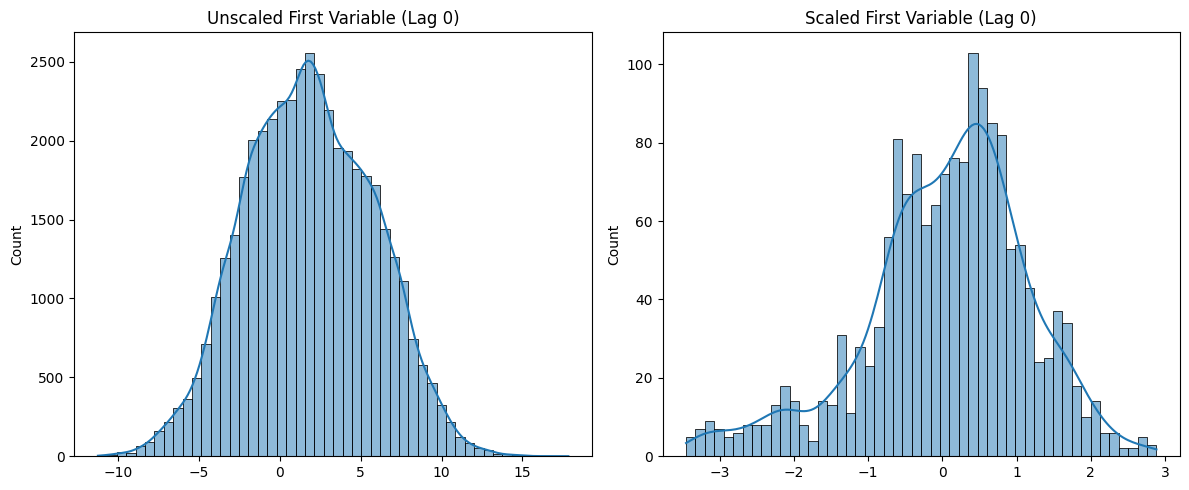

In [190]:
#Histogram of first variable scaled and unscaled for training dataloader
X_train, _ = next(iter(dataloader_train))
X_train_unscaled = pipeline.data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train_unscaled[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Unscaled First Variable (Lag 0)")
plt.subplot(1, 2, 2)
sns.histplot(X_train[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Scaled First Variable (Lag 0)")
plt.tight_layout()